In [1]:
%pip install prophet

  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 4.8 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/12.1 MB 4.8 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/12.1 MB 4.9 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.1 MB 5.0 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/12.1 MB 5.1 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.1 MB 5.1 MB/s eta 0:00:02
   ------------------------ --------------- 7.3/12.1 MB 5.1 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.1 MB 5.2 MB/s eta 0:00:01
   -------------------------------- ------- 9.7/12.1 MB 5.2 MB/s eta 0:00:01
   ----------------------------------- ---- 10.7/12.1 MB 5.2 MB/s eta 0:00:01
   -------------------------------------- - 11.8/12.1 MB 5.2 MB/s eta 0:00:01
   --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\reddy\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import warnings

warnings.filterwarnings("ignore")


In [5]:
df = pd.read_csv(

    "Superstore.csv",

    encoding="latin1"

)

print("\n")

print("="*70)

print("Dataset Loaded Successfully")

print("="*70)



Dataset Loaded Successfully


In [6]:
print("\n")

print("="*70)

print("First Five Records")

print("="*70)

display(

    df.head()

)



First Five Records


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
print("\n")

print("="*70)

print("Last Five Records")

print("="*70)

display(

    df.tail()

)




Last Five Records


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [8]:
print("\n")

print("="*70)

print("Dataset Shape")

print("="*70)

print(

    "Rows    :",

    df.shape[0]

)

print(

    "Columns :",

    df.shape[1]

)




Dataset Shape
Rows    : 9994
Columns : 21


In [9]:
print("\n")

print("="*70)

print("Dataset Information")

print("="*70)

df.info()




Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 1

In [10]:
print("\n")

print("="*70)

print("Column Names")

print("="*70)

print(

    df.columns.tolist()

)



Column Names
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [11]:
print("\n")

print("="*70)

print("Statistical Summary")

print("="*70)

display(

    df.describe()

)




Statistical Summary


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [12]:
print("\n")

print("="*70)

print("Complete Statistical Summary")

print("="*70)

display(

    df.describe(

        include="all"

    )

)



Complete Statistical Summary


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


In [13]:
print("\n")

print("="*70)

print("Missing Values")

print("="*70)

display(

    df.isnull().sum()

)




Missing Values


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [14]:
duplicates = df.duplicated().sum()

print("\n")

print("="*70)

print("Duplicate Records")

print("="*70)

print(

    "Duplicate Records :",

    duplicates

)



Duplicate Records
Duplicate Records : 0


In [15]:
df.drop_duplicates(

    inplace=True

)

print("\n")

print("="*70)

print("Duplicate Records Removed Successfully")

print("="*70)

print(

    "Current Shape :",

    df.shape

)



Duplicate Records Removed Successfully
Current Shape : (9994, 21)


In [16]:
print("\n")

print("="*70)

print("Data Types")

print("="*70)

display(

    df.dtypes

)




Data Types


Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [17]:
df["Order Date"] = pd.to_datetime(

    df["Order Date"]

)

print("\n")

print("="*70)

print("Order Date Converted Successfully")

print("="*70)




Order Date Converted Successfully


In [18]:
df = df.sort_values(

    by="Order Date"

)

print("\n")

print("="*70)

print("Dataset Sorted by Order Date")

print("="*70)




Dataset Sorted by Order Date


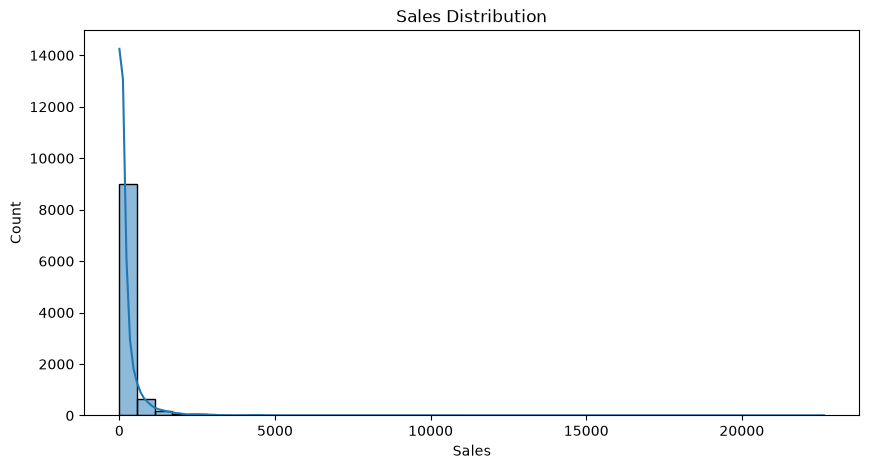

In [19]:
plt.figure(

    figsize=(10,5)

)

sns.histplot(

    df["Sales"],

    bins=40,

    kde=True

)

plt.title(

    "Sales Distribution"

)

plt.xlabel(

    "Sales"

)

plt.show()


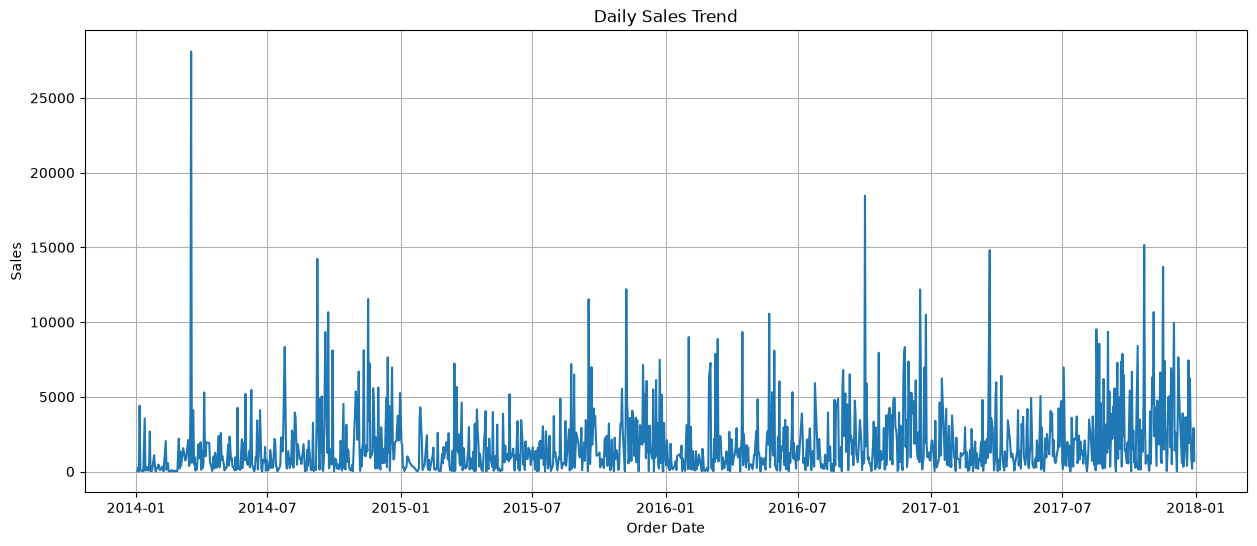

In [20]:
daily_sales = df.groupby(

    "Order Date"

)["Sales"].sum()

plt.figure(

    figsize=(15,6)

)

plt.plot(

    daily_sales

)

plt.title(

    "Daily Sales Trend"

)

plt.xlabel(

    "Order Date"

)

plt.ylabel(

    "Sales"

)

plt.grid()

plt.show()


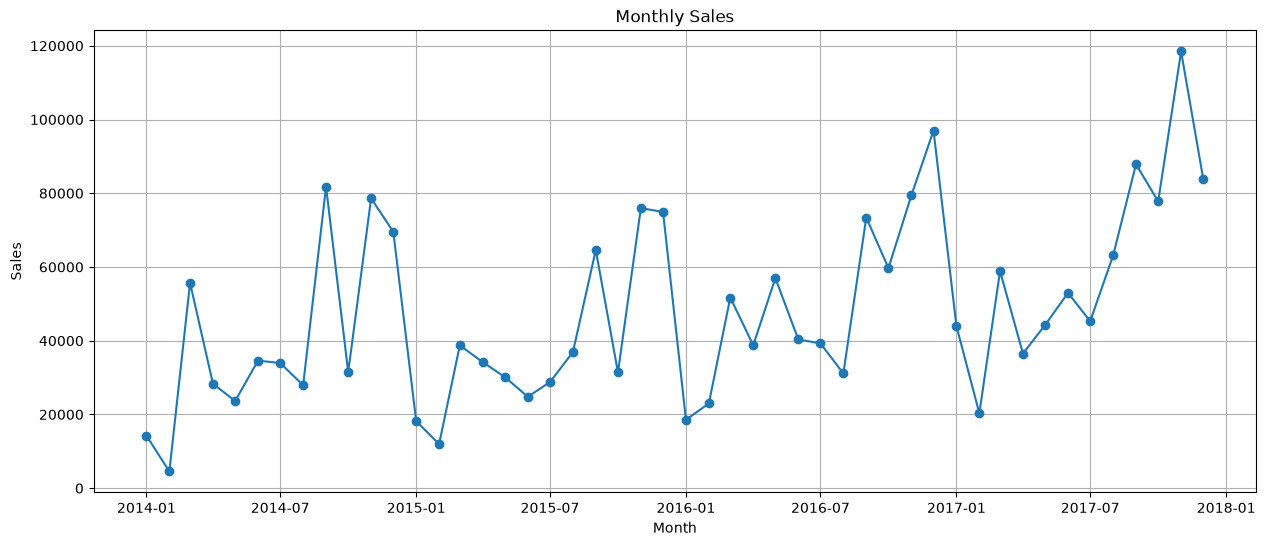

In [22]:
monthly_sales = df.groupby(

    df["Order Date"].dt.to_period("M")

)["Sales"].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(

    figsize=(15,6)

)

plt.plot(

    monthly_sales,

    marker="o"

)

plt.title(

    "Monthly Sales"

)

plt.xlabel(

    "Month"

)

plt.ylabel(

    "Sales"

)

plt.grid()

plt.show()

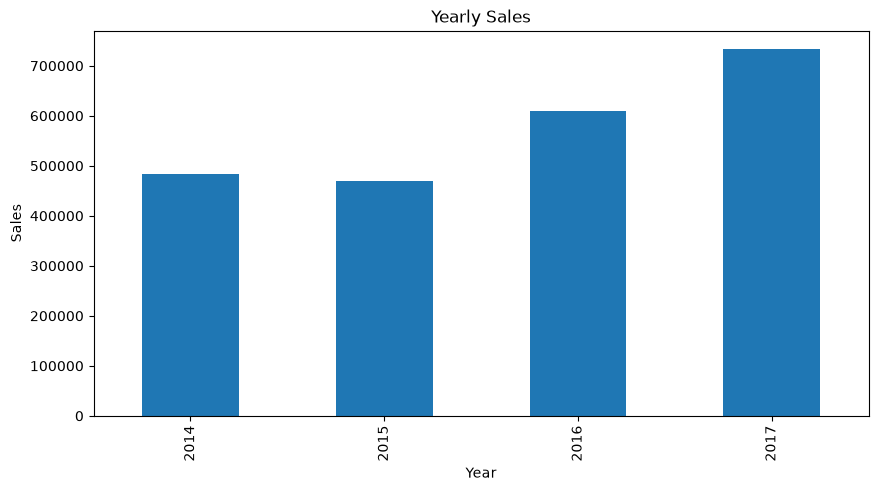

In [23]:
yearly_sales = df.groupby(

    df["Order Date"].dt.year

)["Sales"].sum()

plt.figure(

    figsize=(10,5)

)

yearly_sales.plot(

    kind="bar"

)

plt.title(

    "Yearly Sales"

)

plt.xlabel(

    "Year"

)

plt.ylabel(

    "Sales"

)

plt.show()


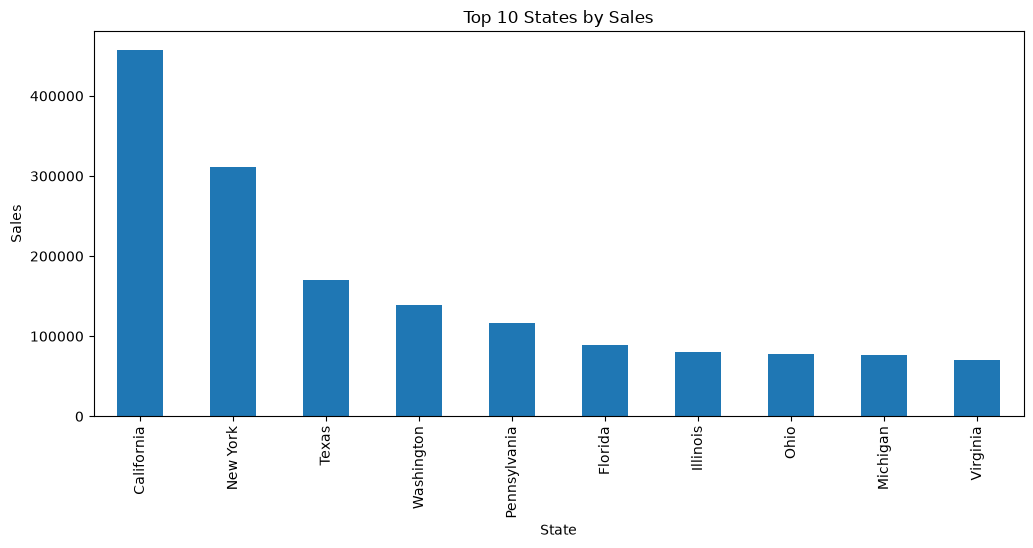

In [24]:
top_states = df.groupby(

    "State"

)["Sales"].sum().sort_values(

    ascending=False

).head(10)

plt.figure(

    figsize=(12,5)

)

top_states.plot(

    kind="bar"

)

plt.title(

    "Top 10 States by Sales"

)

plt.ylabel(

    "Sales"

)

plt.show()


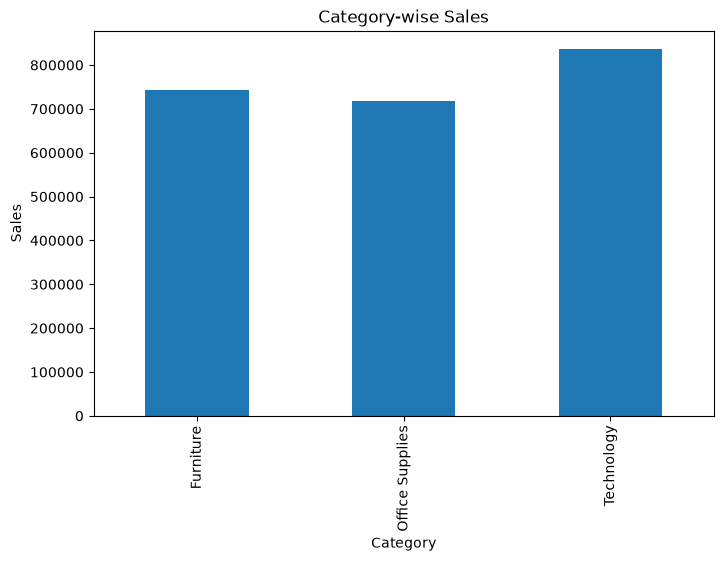

In [25]:
category_sales = df.groupby(

    "Category"

)["Sales"].sum()

plt.figure(

    figsize=(8,5)

)

category_sales.plot(

    kind="bar"

)

plt.title(

    "Category-wise Sales"

)

plt.ylabel(

    "Sales"

)

plt.show()


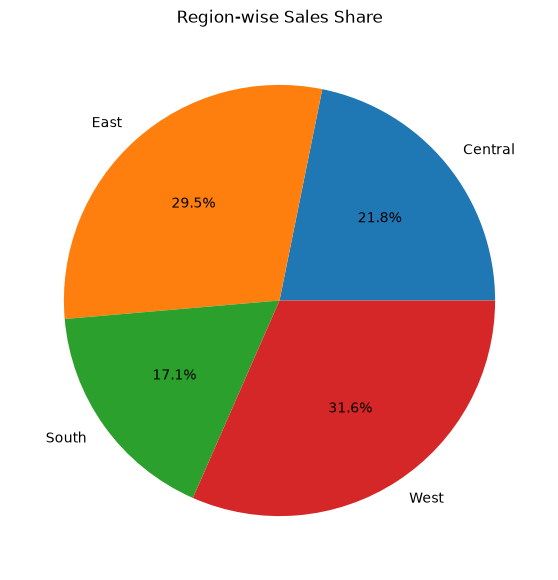

In [26]:
region_sales = df.groupby(

    "Region"

)["Sales"].sum()

plt.figure(

    figsize=(7,7)

)

region_sales.plot(

    kind="pie",

    autopct="%1.1f%%"

)

plt.ylabel("")

plt.title(

    "Region-wise Sales Share"

)

plt.show()



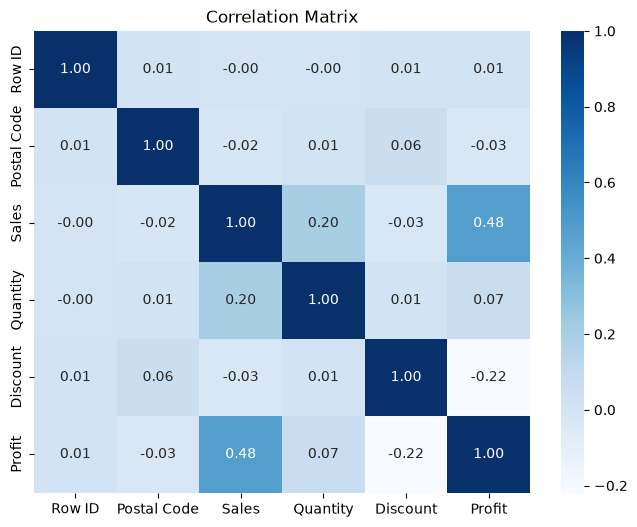

In [27]:
numeric_df = df.select_dtypes(

    include=np.number

)

plt.figure(

    figsize=(8,6)

)

sns.heatmap(

    numeric_df.corr(),

    annot=True,

    cmap="Blues",

    fmt=".2f"

)

plt.title(

    "Correlation Matrix"

)

plt.show()


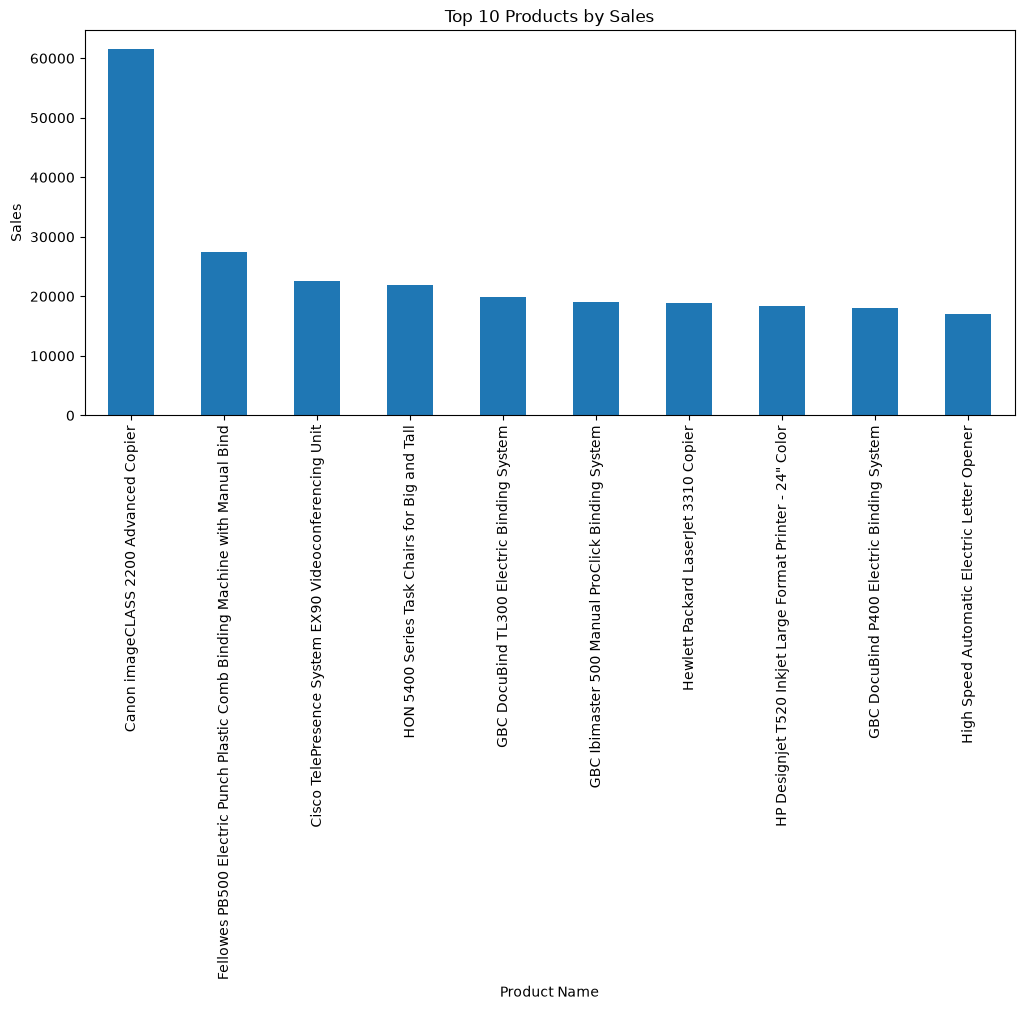

In [28]:
top_products = df.groupby(

    "Product Name"

)["Sales"].sum().sort_values(

    ascending=False

).head(10)

plt.figure(

    figsize=(12,5)

)

top_products.plot(

    kind="bar"

)

plt.title(

    "Top 10 Products by Sales"

)

plt.ylabel(

    "Sales"

)

plt.show()


In [29]:
print("\n")

print("="*70)

print("Dataset Summary")

print("="*70)

print(

    "Total Records       :",

    df.shape[0]

)

print(

    "Total Features      :",

    df.shape[1]

)

print(

    "Date Range          :",

    df["Order Date"].min(),

    "to",

    df["Order Date"].max()

)

print(

    "Total Sales         :",

    round(

        df["Sales"].sum(),

        2

    )

)

print(

    "Average Sales       :",

    round(

        df["Sales"].mean(),

        2

    )

)

print(

    "Maximum Sale        :",

    round(

        df["Sales"].max(),

        2

    )

)

print(

    "Minimum Sale        :",

    round(

        df["Sales"].min(),

        2

    )

)

print("="*70)




Dataset Summary
Total Records       : 9994
Total Features      : 21
Date Range          : 2014-01-03 00:00:00 to 2017-12-30 00:00:00
Total Sales         : 2297200.86
Average Sales       : 229.86
Maximum Sale        : 22638.48
Minimum Sale        : 0.44


In [30]:
print("\n")

print("="*70)

print("Missing Values Before Treatment")

print("="*70)

display(

    df.isnull().sum()

)



Missing Values Before Treatment


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [33]:
df.ffill(inplace=True) 

df.bfill(inplace=True) 

print("\n")

print("="*70)

print("Missing Values After Treatment")

print("="*70)

display(

    df.isnull().sum()

)



Missing Values After Treatment


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [34]:
duplicates = df.duplicated().sum()

print("\n")

print("="*70)

print("Duplicate Records")

print("="*70)

print(

    "Duplicate Records :",

    duplicates

)

df.drop_duplicates(

    inplace=True

)

print("\n")

print("="*70)

print("Duplicate Records Removed Successfully")

print("="*70)

print(

    "Current Shape :",

    df.shape

)




Duplicate Records
Duplicate Records : 0


Duplicate Records Removed Successfully
Current Shape : (9994, 21)


In [35]:
prophet_df = df[[

    "Order Date",

    "Sales"

]].copy()

print("\n")

print("="*70)

print("Required Columns Selected")

print("="*70)

display(

    prophet_df.head()

)



Required Columns Selected


,Order Date,Sales
7980,2014-01-03,16.448
739,2014-01-04,11.784
740,2014-01-04,272.736
741,2014-01-04,3.540
1759,2014-01-05,19.536


In [36]:
prophet_df.rename(

    columns={

        "Order Date":"ds",

        "Sales":"y"

    },

    inplace=True

)

print("\n")

print("="*70)

print("Columns Renamed Successfully")

print("="*70)

display(

    prophet_df.head()

)




Columns Renamed Successfully


,ds,y
7980,2014-01-03,16.448
739,2014-01-04,11.784
740,2014-01-04,272.736
741,2014-01-04,3.540
1759,2014-01-05,19.536


In [37]:
prophet_df = prophet_df.groupby(

    "ds",

    as_index=False

)["y"].sum()

print("\n")

print("="*70)

print("Daily Sales Aggregated")

print("="*70)

display(

    prophet_df.head()

)




Daily Sales Aggregated


,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [38]:
prophet_df["ds"] = pd.to_datetime(

    prophet_df["ds"]

)

print("\n")

print("="*70)

print("Date Format Converted")

print("="*70)




Date Format Converted


In [39]:
prophet_df = prophet_df.sort_values(

    by="ds"

)

print("\n")

print("="*70)

print("Dataset Sorted Successfully")

print("="*70)



Dataset Sorted Successfully


In [40]:
prophet_df.reset_index(

    drop=True,

    inplace=True

)

print("\n")

print("="*70)

print("Index Reset Successfully")

print("="*70)



Index Reset Successfully


In [41]:

print("\n")

print("="*70)

print("Prophet Dataset Information")

print("="*70)

display(

    prophet_df.head()

)

display(

    prophet_df.tail()

)



Prophet Dataset Information


,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


,ds,y
1232,2017-12-26,814.5940
1233,2017-12-27,177.6360
1234,2017-12-28,1657.3508
1235,2017-12-29,2915.5340
1236,2017-12-30,713.7900


In [42]:
print("\n")

print("="*70)

print("Dataset Shape")

print("="*70)

print(

    "Rows :",

    prophet_df.shape[0]

)

print(

    "Columns :",

    prophet_df.shape[1]

)




Dataset Shape
Rows : 1237
Columns : 2


In [43]:
print("\n")

print("="*70)

print("Data Types")

print("="*70)

display(

    prophet_df.dtypes

)



Data Types


ds    datetime64[us]
y            float64
dtype: object

In [44]:
print("\n")

print("="*70)

print("Final Missing Values")

print("="*70)

display(

    prophet_df.isnull().sum()

)




Final Missing Values


ds    0
y     0
dtype: int64

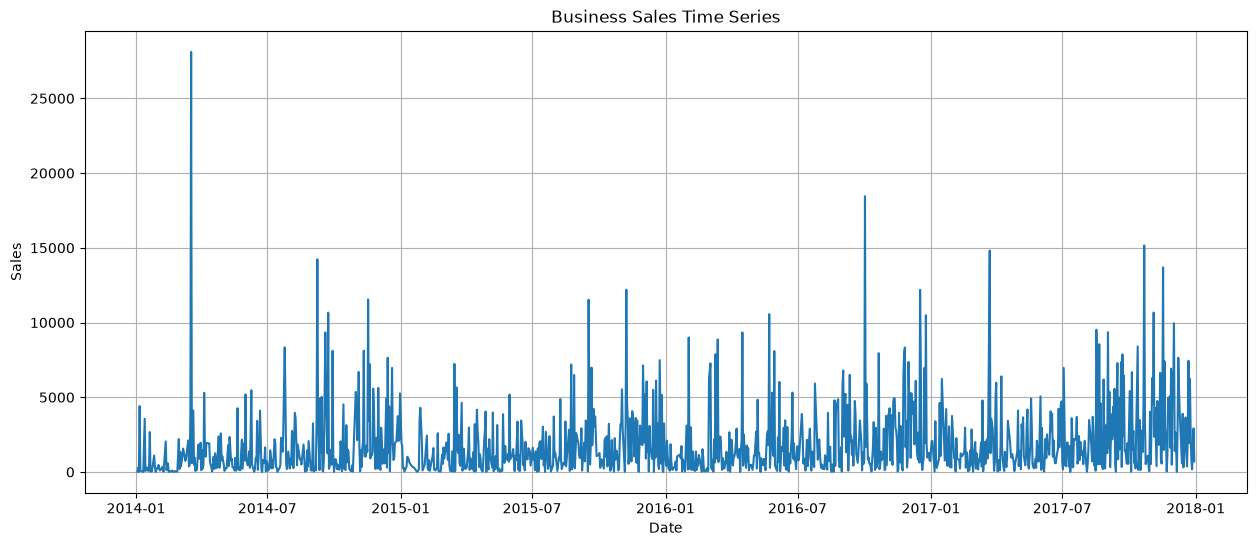

In [45]:
plt.figure(

    figsize=(15,6)

)

plt.plot(

    prophet_df["ds"],

    prophet_df["y"]

)

plt.title(

    "Business Sales Time Series"

)

plt.xlabel(

    "Date"

)

plt.ylabel(

    "Sales"

)

plt.grid()

plt.show()


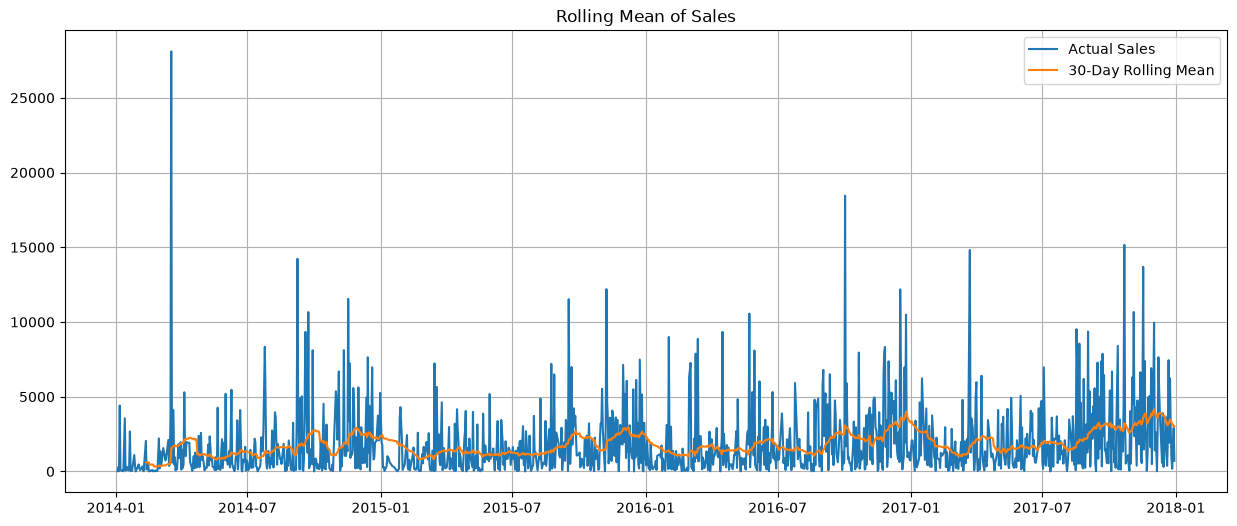

In [46]:
prophet_df["Rolling_Mean"] = prophet_df["y"].rolling(

    window=30

).mean()

plt.figure(

    figsize=(15,6)

)

plt.plot(

    prophet_df["ds"],

    prophet_df["y"],

    label="Actual Sales"

)

plt.plot(

    prophet_df["ds"],

    prophet_df["Rolling_Mean"],

    label="30-Day Rolling Mean"

)

plt.legend()

plt.grid()

plt.title(

    "Rolling Mean of Sales"

)

plt.show()


In [47]:
train_size = int(

    len(prophet_df) * 0.80

)

train = prophet_df.iloc[:train_size]

test = prophet_df.iloc[train_size:]

print("\n")

print("="*70)

print("Train-Test Split")

print("="*70)

print(

    "Training Records :",

    len(train)

)

print(

    "Testing Records :",

    len(test)

)




Train-Test Split
Training Records : 989
Testing Records : 248


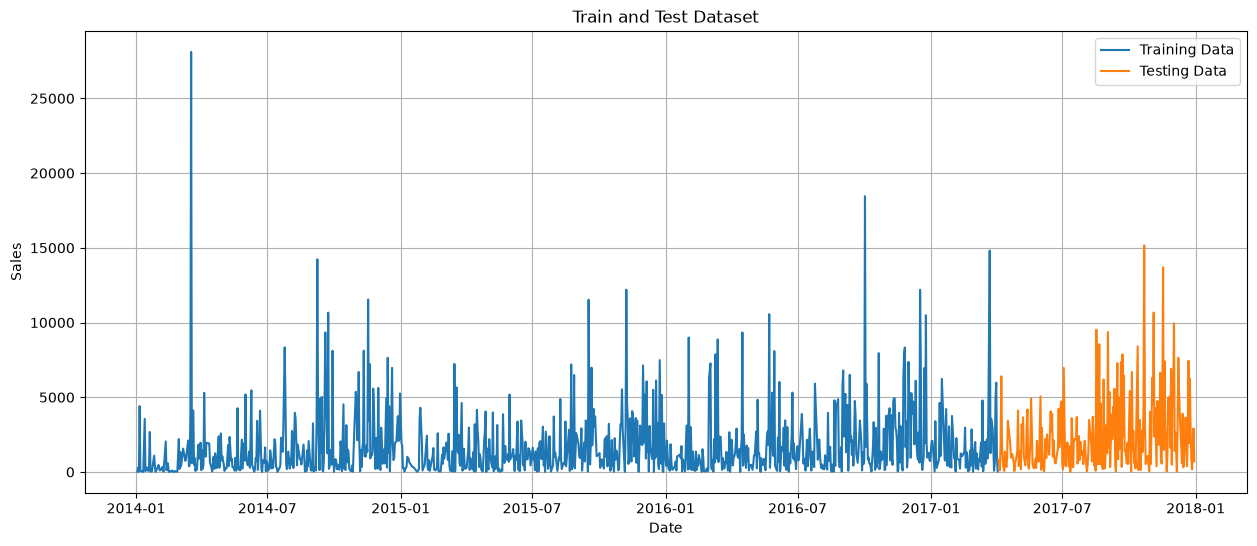

In [48]:
plt.figure(

    figsize=(15,6)

)

plt.plot(

    train["ds"],

    train["y"],

    label="Training Data"

)

plt.plot(

    test["ds"],

    test["y"],

    label="Testing Data"

)

plt.legend()

plt.grid()

plt.title(

    "Train and Test Dataset"

)

plt.xlabel(

    "Date"

)

plt.ylabel(

    "Sales"

)

plt.show()


In [49]:
print("\n")

print("="*70)

print("Dataset Summary")

print("="*70)

print(

    "Total Records        :",

    len(prophet_df)

)

print(

    "Training Records     :",

    len(train)

)

print(

    "Testing Records      :",

    len(test)

)

print(

    "Start Date           :",

    prophet_df["ds"].min()

)

print(

    "End Date             :",

    prophet_df["ds"].max()

)

print(

    "Maximum Sales        :",

    round(

        prophet_df["y"].max(),

        2

    )

)

print(

    "Minimum Sales        :",

    round(

        prophet_df["y"].min(),

        2

    )

)

print(

    "Average Sales        :",

    round(

        prophet_df["y"].mean(),

        2

    )

)

print("="*70)



Dataset Summary
Total Records        : 1237
Training Records     : 989
Testing Records      : 248
Start Date           : 2014-01-03 00:00:00
End Date             : 2017-12-30 00:00:00
Maximum Sales        : 28106.72
Minimum Sales        : 2.02
Average Sales        : 1857.07


In [50]:
print("\n")

print("="*70)

print("Dataset Ready for Prophet Model")

print("="*70)




Dataset Ready for Prophet Model


In [ ]:
from prophet import Prophet

from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

import numpy as np

In [53]:
model = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=True,

    daily_seasonality=False

)

print("\n")

print("="*70)

print("Prophet Model Created Successfully")

print("="*70)



Prophet Model Created Successfully


In [54]:
model.fit(

    train

)

print("\n")

print("="*70)

print("Model Training Completed")

print("="*70)


11:52:06 - cmdstanpy - INFO - Chain [1] start processing
11:52:09 - cmdstanpy - INFO - Chain [1] done processing




Model Training Completed


In [55]:
future = model.make_future_dataframe(

    periods=len(test),

    freq="D"

)

print("\n")

print("="*70)

print("Future Dates Generated")

print("="*70)

display(

    future.tail()

)



Future Dates Generated


,ds
1232,2017-12-03
1233,2017-12-04
1234,2017-12-05
1235,2017-12-06
1236,2017-12-07


In [56]:
forecast = model.predict(

    future

)

print("\n")

print("="*70)

print("Forecast Generated Successfully")

print("="*70)

display(

    forecast[

        [

            "ds",

            "yhat",

            "yhat_lower",

            "yhat_upper"

        ]

    ].tail()

)




Forecast Generated Successfully


,ds,yhat,yhat_lower,yhat_upper
1232,2017-12-03,3186.624853,326.244670,5822.133494
1233,2017-12-04,3409.112945,772.400958,5993.099882
1234,2017-12-05,3124.800302,580.759032,5847.094333
1235,2017-12-06,2179.403449,-711.990124,4870.216849
1236,2017-12-07,3215.072489,331.431070,5946.717574


In [57]:
predictions = forecast[

    [

        "ds",

        "yhat"

    ]

].tail(

    len(test)

)

predictions.reset_index(

    drop=True,

    inplace=True

)

test.reset_index(

    drop=True,

    inplace=True

)


In [58]:
mae = mean_absolute_error(

    test["y"],

    predictions["yhat"]

)

mse = mean_squared_error(

    test["y"],

    predictions["yhat"]

)

rmse = np.sqrt(

    mse

)

print("\n")

print("="*70)

print("Evaluation Metrics")

print("="*70)

print(

    "MAE  :",

    round(

        mae,

        2

    )

)

print(

    "MSE  :",

    round(

        mse,

        2

    )

)

print(

    "RMSE :",

    round(

        rmse,

        2

    )

)




Evaluation Metrics
MAE  : 1809.24
MSE  : 6400390.39
RMSE : 2529.9


In [59]:
comparison = pd.DataFrame({

    "Date": test["ds"],

    "Actual Sales": test["y"],

    "Predicted Sales": predictions["yhat"]

})

print("\n")

print("="*70)

print("Actual vs Predicted")

print("="*70)

display(

    comparison.head(

        20

    )

)




Actual vs Predicted


,Date,Actual Sales,Predicted Sales
0,2017-04-04,808.4700,1774.331027
1,2017-04-06,114.4200,778.155775
2,2017-04-07,1971.2905,1765.110389
3,2017-04-08,6401.9300,1982.428184
4,2017-04-09,1626.7100,1611.135361
5,2017-04-10,755.5290,1849.280064
6,2017-04-11,319.8060,2055.355644
7,2017-04-12,69.6600,1751.323767
8,2017-04-13,1345.8240,782.844197
9,2017-04-14,652.9300,1792.173477


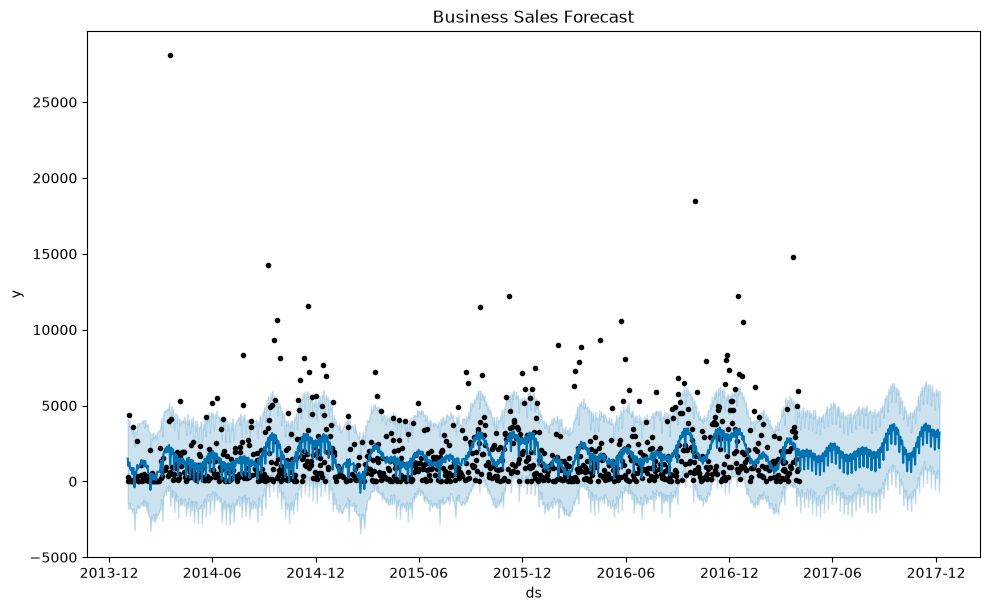

In [60]:
fig1 = model.plot(

    forecast

)

plt.title(

    "Business Sales Forecast"

)

plt.grid()

plt.show()

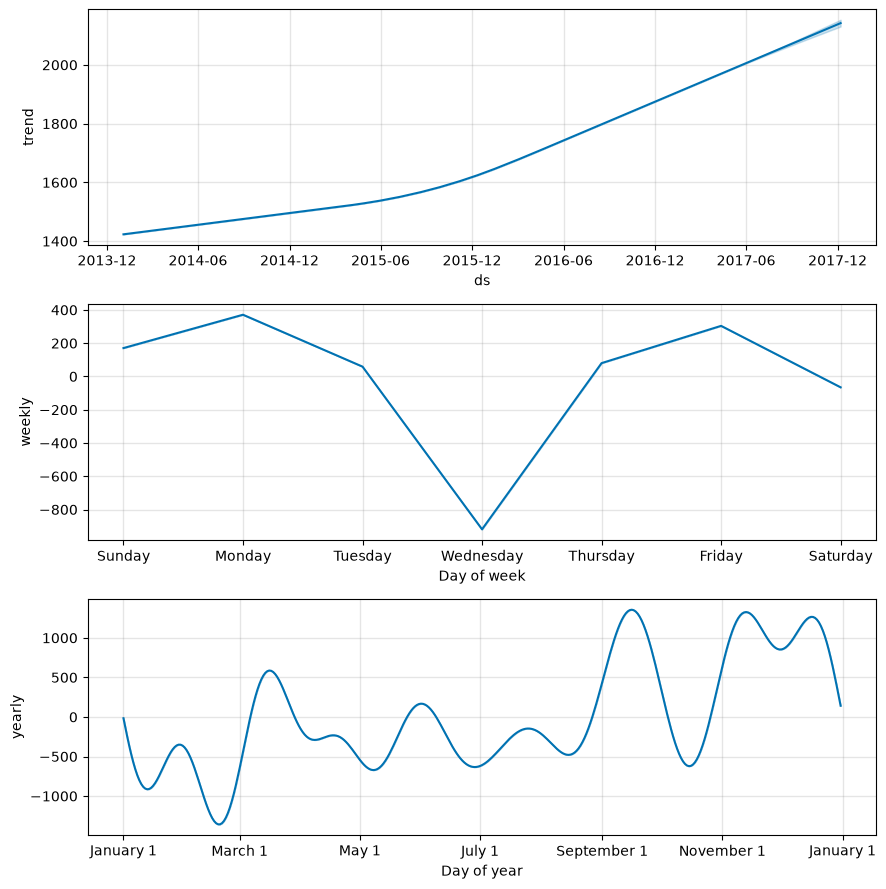

In [61]:
fig2 = model.plot_components(

    forecast

)

plt.show()


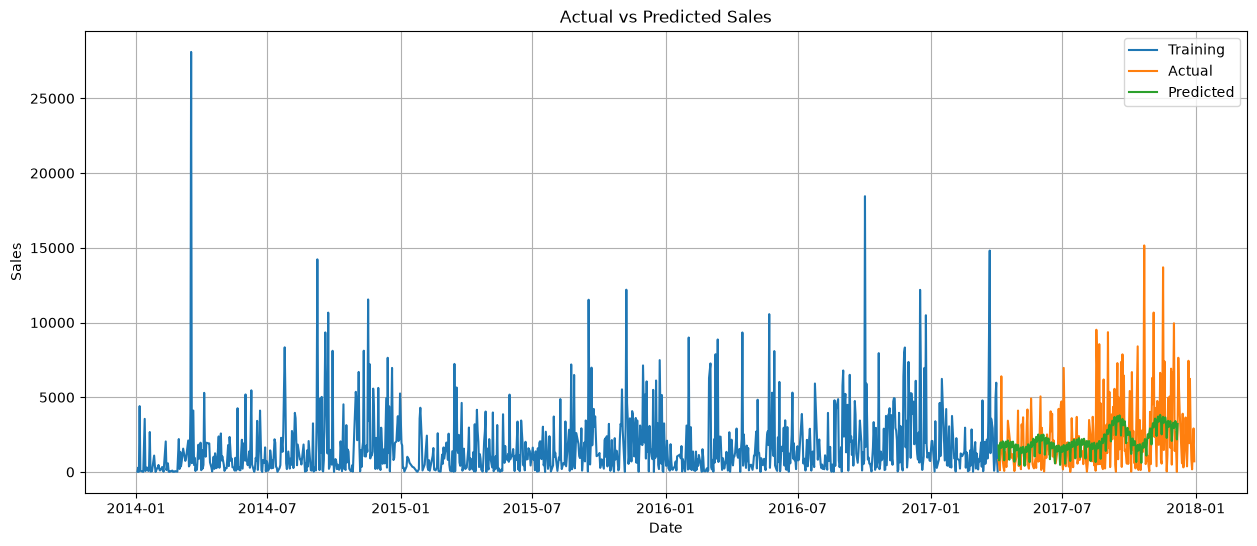

In [62]:
plt.figure(

    figsize=(15,6)

)

plt.plot(

    train["ds"],

    train["y"],

    label="Training"

)

plt.plot(

    test["ds"],

    test["y"],

    label="Actual"

)

plt.plot(

    predictions["ds"],

    predictions["yhat"],

    label="Predicted"

)

plt.legend()

plt.grid()

plt.title(

    "Actual vs Predicted Sales"

)

plt.xlabel(

    "Date"

)

plt.ylabel(

    "Sales"

)

plt.show()


In [63]:
future_30 = model.make_future_dataframe(

    periods=30,

    freq="D"

)

forecast_30 = model.predict(

    future_30

)

future_predictions = forecast_30.tail(

    30

)[

    [

        "ds",

        "yhat",

        "yhat_lower",

        "yhat_upper"

    ]

]

print("\n")

print("="*70)

print("Next 30 Days Forecast")

print("="*70)

display(

    future_predictions

)




Next 30 Days Forecast


,ds,yhat,yhat_lower,yhat_upper
989,2017-04-04,1774.331027,-1090.545798,4303.007050
990,2017-04-05,778.155775,-1923.336427,3674.484243
991,2017-04-06,1765.110389,-817.993516,4568.547766
992,2017-04-07,1982.428184,-844.064235,4684.355664
993,2017-04-08,1611.135361,-1060.518563,4117.837875
994,2017-04-09,1849.280064,-930.656518,4601.312015
995,2017-04-10,2055.355644,-530.294146,4863.851868
996,2017-04-11,1751.323767,-737.688167,4245.685411
997,2017-04-12,782.844197,-2094.528710,3383.992315
998,2017-04-13,1792.173477,-840.753561,4447.537344


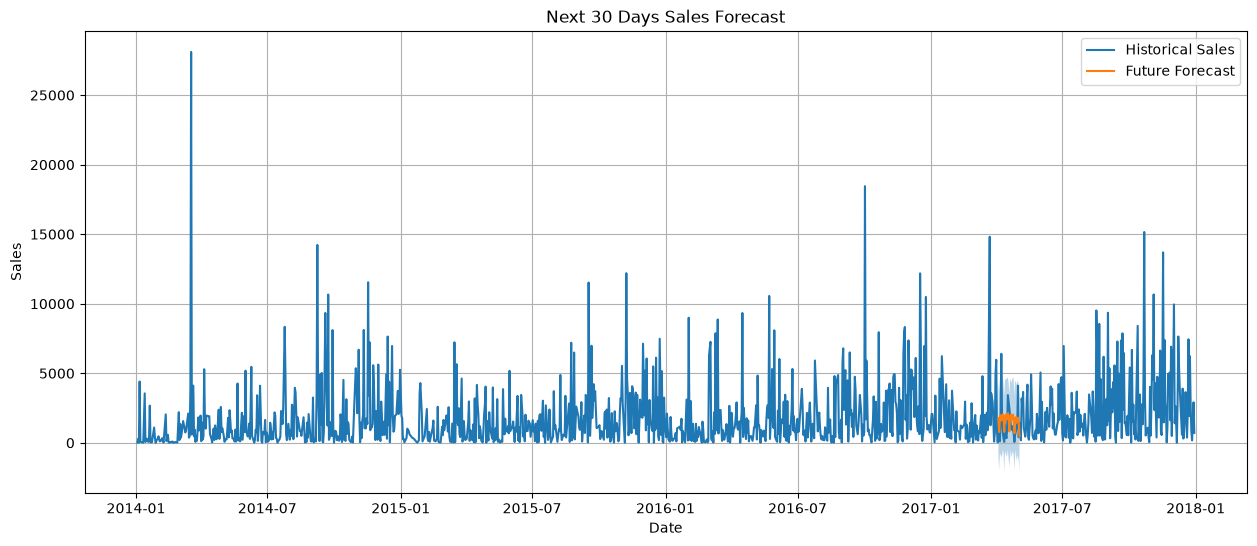

In [64]:
plt.figure(

    figsize=(15,6)

)

plt.plot(

    prophet_df["ds"],

    prophet_df["y"],

    label="Historical Sales"

)

plt.plot(

    future_predictions["ds"],

    future_predictions["yhat"],

    label="Future Forecast"

)

plt.fill_between(

    future_predictions["ds"],

    future_predictions["yhat_lower"],

    future_predictions["yhat_upper"],

    alpha=0.3

)

plt.legend()

plt.grid()

plt.title(

    "Next 30 Days Sales Forecast"

)

plt.xlabel(

    "Date"

)

plt.ylabel(

    "Sales"

)

plt.show()


In [65]:
print("\n")

print("="*70)

print("Forecast Summary")

print("="*70)

display(

    future_predictions.describe()

)



Forecast Summary


,ds,yhat,yhat_lower,yhat_upper
count,30,30.000000,30.000000,30.000000
mean,2017-04-18 12:00:00,1618.172923,-1059.733813,4297.405456
min,2017-04-04 00:00:00,463.769174,-2094.528710,3171.737049
25%,2017-04-11 06:00:00,1618.256097,-1115.369518,4180.203046
50%,2017-04-18 12:00:00,1769.720708,-955.345344,4417.834341
75%,2017-04-25 18:00:00,1854.180215,-779.054285,4611.935448
max,2017-05-03 00:00:00,2112.329729,-530.294146,4863.851868
std,NaN,448.168275,453.219535,445.037322


In [66]:
print("\n")

print("="*70)

print("Business Insights")

print("="*70)

print("- Prophet automatically detects trend and seasonality.")

print("- Weekly and yearly seasonal patterns improve forecasting accuracy.")

print("- Confidence intervals show uncertainty in future predictions.")

print("- Forecasts support inventory planning and sales strategy.")

print("- Retraining with new sales data improves long-term performance.")




Business Insights
- Prophet automatically detects trend and seasonality.
- Weekly and yearly seasonal patterns improve forecasting accuracy.
- Confidence intervals show uncertainty in future predictions.
- Forecasts support inventory planning and sales strategy.
- Retraining with new sales data improves long-term performance.


In [67]:
print("\n")

print("="*70)

print("Prophet Model Summary")

print("="*70)

print(

    "Algorithm               : Prophet"

)

print(

    "Training Records        :",

    len(train)

)

print(

    "Testing Records         :",

    len(test)

)

print(

    "Forecast Horizon        : 30 Days"

)

print(

    "MAE                     :",

    round(

        mae,

        2

    )

)

print(

    "MSE                     :",

    round(

        mse,

        2

    )

)

print(

    "RMSE                    :",

    round(

        rmse,

        2

    )

)

print("="*70)




Prophet Model Summary
Algorithm               : Prophet
Training Records        : 989
Testing Records         : 248
Forecast Horizon        : 30 Days
MAE                     : 1809.24
MSE                     : 6400390.39
RMSE                    : 2529.9


In [68]:
import joblib

In [69]:
joblib.dump(

    model,

    "prophet_business_forecasting_model.joblib"

)

print("\n")

print("="*70)

print("Prophet Model Saved Successfully")

print("="*70)



Prophet Model Saved Successfully


In [70]:
loaded_model = joblib.load(

    "prophet_business_forecasting_model.joblib"

)

print("\n")

print("="*70)

print("Saved Prophet Model Loaded Successfully")

print("="*70)



Saved Prophet Model Loaded Successfully


In [71]:
future = loaded_model.make_future_dataframe(

    periods=30,

    freq="D"

)

In [72]:
future_forecast = loaded_model.predict(

    future

)

forecast_output = future_forecast.tail(

    30

)[

    [

        "ds",

        "yhat",

        "yhat_lower",

        "yhat_upper"

    ]

]

print("\n")

print("="*70)

print("Next 30 Days Business Forecast")

print("="*70)

display(

    forecast_output

)




Next 30 Days Business Forecast


,ds,yhat,yhat_lower,yhat_upper
989,2017-04-04,1774.331027,-732.113960,4717.225946
990,2017-04-05,778.155775,-1898.252933,3450.591621
991,2017-04-06,1765.110389,-956.318331,4500.806925
992,2017-04-07,1982.428184,-892.010889,4615.979957
993,2017-04-08,1611.135361,-1216.112077,4382.974427
994,2017-04-09,1849.280064,-919.363795,4415.478420
995,2017-04-10,2055.355644,-698.144954,4956.465338
996,2017-04-11,1751.323767,-983.455933,4190.926127
997,2017-04-12,782.844197,-1747.381452,3524.462514
998,2017-04-13,1792.173477,-687.430917,4612.115926


In [73]:
forecast_output.to_csv(

    "Future_Business_Forecast.csv",

    index=False

)

print("\n")

print("="*70)

print("Forecast Results Exported Successfully")

print("="*70)



Forecast Results Exported Successfully


In [74]:
metrics = pd.DataFrame({

    "Metric":[

        "MAE",

        "MSE",

        "RMSE"

    ],

    "Value":[

        mae,

        mse,

        rmse

    ]

})

metrics.to_csv(

    "Evaluation_Metrics.csv",

    index=False

)

print("\n")

print("="*70)

print("Evaluation Metrics Saved Successfully")

print("="*70)

display(

    metrics

)




Evaluation Metrics Saved Successfully


,Metric,Value
0,MAE,1.809235e+03
1,MSE,6.400390e+06
2,RMSE,2.529899e+03


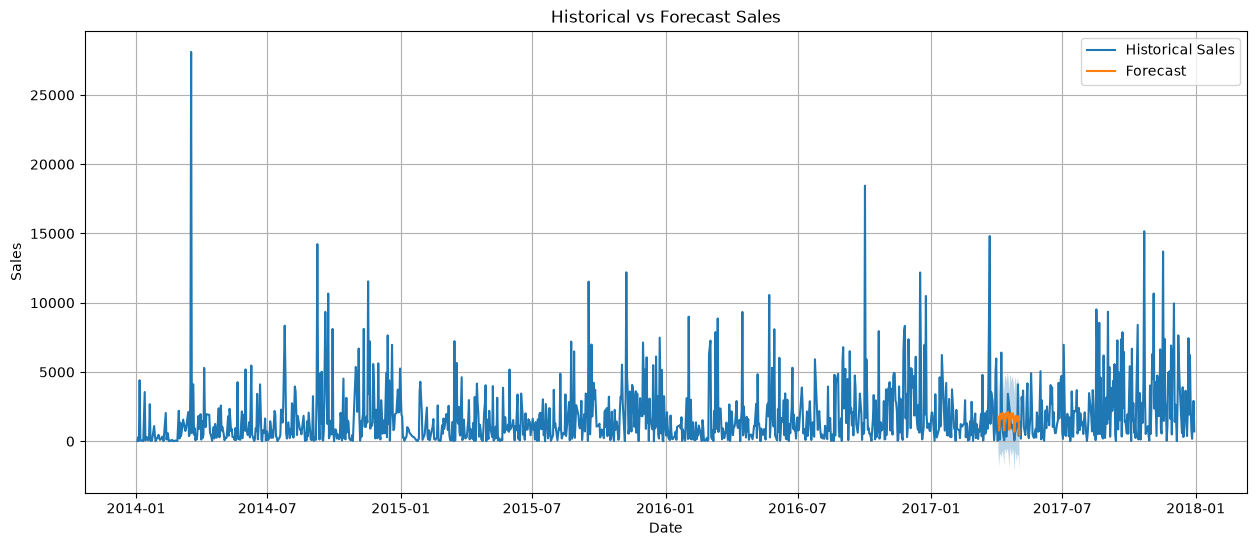

In [75]:
plt.figure(

    figsize=(15,6)

)

plt.plot(

    prophet_df["ds"],

    prophet_df["y"],

    label="Historical Sales"

)

plt.plot(

    forecast_output["ds"],

    forecast_output["yhat"],

    label="Forecast"

)

plt.fill_between(

    forecast_output["ds"],

    forecast_output["yhat_lower"],

    forecast_output["yhat_upper"],

    alpha=0.3

)

plt.legend()

plt.grid()

plt.title(

    "Historical vs Forecast Sales"

)

plt.xlabel(

    "Date"

)

plt.ylabel(

    "Sales"

)

plt.show()


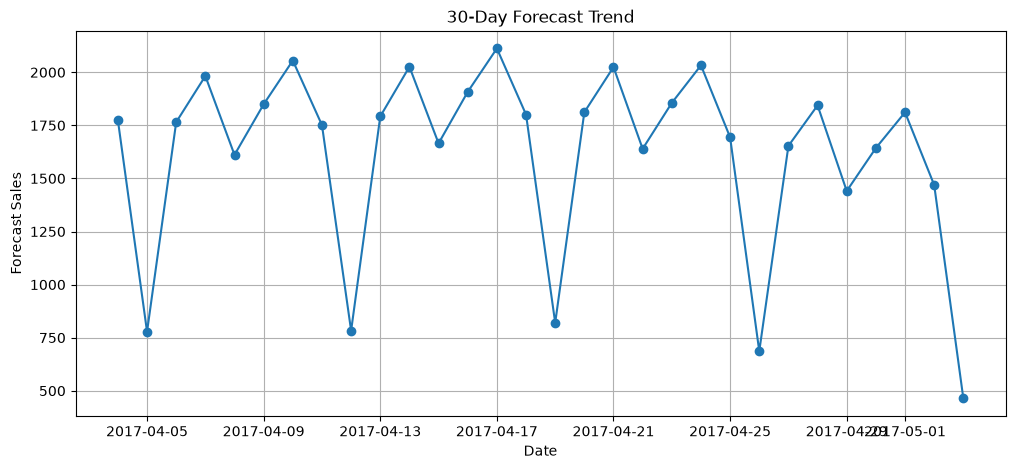

In [76]:
plt.figure(

    figsize=(12,5)

)

plt.plot(

    forecast_output["ds"],

    forecast_output["yhat"],

    marker="o"

)

plt.title(

    "30-Day Forecast Trend"

)

plt.xlabel(

    "Date"

)

plt.ylabel(

    "Forecast Sales"

)

plt.grid()

plt.show()


In [77]:
forecast_statistics = forecast_output.describe()

print("\n")

print("="*70)

print("Forecast Statistics")

print("="*70)

display(

    forecast_statistics

)




Forecast Statistics


,ds,yhat,yhat_lower,yhat_upper
count,30,30.000000,30.000000,30.000000
mean,2017-04-18 12:00:00,1618.172923,-1057.681197,4321.749255
min,2017-04-04 00:00:00,463.769174,-2215.451355,3000.025258
25%,2017-04-11 06:00:00,1618.256097,-1128.194100,4192.889207
50%,2017-04-18 12:00:00,1769.720708,-934.097755,4443.830310
75%,2017-04-25 18:00:00,1854.180215,-706.637206,4634.413591
max,2017-05-03 00:00:00,2112.329729,-447.661558,4985.015327
std,NaN,448.168275,475.455096,489.933574


In [78]:
model_information = pd.DataFrame({

    "Parameter":[

        "Algorithm",

        "Model",

        "Training Records",

        "Testing Records",

        "Forecast Horizon",

        "Prediction Interval"

    ],

    "Value":[

        "Time Series Forecasting",

        "Facebook Prophet",

        len(train),

        len(test),

        "30 Days",

        "95% Confidence"

    ]

})

print("\n")

print("="*70)

print("Model Information")

print("="*70)

display(

    model_information

)




Model Information


,Parameter,Value
0,Algorithm,Time Series Forecasting
1,Model,Facebook Prophet
2,Training Records,989
3,Testing Records,248
4,Forecast Horizon,30 Days
5,Prediction Interval,95% Confidence


In [79]:
deployment_summary = pd.DataFrame({

    "File":[

        "Trained Prophet Model",

        "Business Forecast",

        "Evaluation Metrics"

    ],

    "Saved As":[

        "prophet_business_forecasting_model.joblib",

        "Future_Business_Forecast.csv",

        "Evaluation_Metrics.csv"

    ]

})

print("\n")

print("="*70)

print("Deployment Summary")

print("="*70)

display(

    deployment_summary

)




Deployment Summary


,File,Saved As
0,Trained Prophet Model,prophet_business_forecasting_model.joblib
1,Business Forecast,Future_Business_Forecast.csv
2,Evaluation Metrics,Evaluation_Metrics.csv


In [80]:
print("\n")

print("="*70)

print("Business Insights")

print("="*70)

print("- Prophet automatically models trend, weekly, and yearly seasonality.")

print("- Forecast confidence intervals help quantify uncertainty.")

print("- Future sales forecasts support inventory planning and budgeting.")

print("- Businesses can optimize staffing and supply chain decisions.")

print("- Retraining the model periodically improves forecasting accuracy.")



Business Insights
- Prophet automatically models trend, weekly, and yearly seasonality.
- Forecast confidence intervals help quantify uncertainty.
- Future sales forecasts support inventory planning and budgeting.
- Businesses can optimize staffing and supply chain decisions.
- Retraining the model periodically improves forecasting accuracy.


In [81]:
print("\n")

print("="*70)

print("Business Forecasting using Prophet")

print("="*70)

print("Dataset                 : Superstore Sales Dataset")

print("Algorithm               : Facebook Prophet")

print("Training Records        :", len(train))

print("Testing Records         :", len(test))

print("Forecast Horizon        : 30 Days")

print("MAE                     :", round(mae,2))

print("MSE                     :", round(mse,2))

print("RMSE                    :", round(rmse,2))

print("Prediction Interval     : 95% Confidence")

print("Model Saved             : prophet_business_forecasting_model.joblib")

print("Forecast File           : Future_Business_Forecast.csv")

print("Metrics File            : Evaluation_Metrics.csv")

print("Project Status          : Deployment Ready")

print("="*70)




Business Forecasting using Prophet
Dataset                 : Superstore Sales Dataset
Algorithm               : Facebook Prophet
Training Records        : 989
Testing Records         : 248
Forecast Horizon        : 30 Days
MAE                     : 1809.24
MSE                     : 6400390.39
RMSE                    : 2529.9
Prediction Interval     : 95% Confidence
Model Saved             : prophet_business_forecasting_model.joblib
Forecast File           : Future_Business_Forecast.csv
Metrics File            : Evaluation_Metrics.csv
Project Status          : Deployment Ready


In [82]:
print("\n")

print("="*70)

print("Business Forecasting using Prophet Completed Successfully!")

print("="*70)




Business Forecasting using Prophet Completed Successfully!
